In [11]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. LOAD AND CONCATENATE 4 CSVS (WITH DAY INJECTION)
price_files = ['Data (Raw CSV)/prices_round_0_day_-1.csv', 'Data (Raw CSV)/prices_round_0_day_-2.csv']
trade_files = ['Data (Raw CSV)/trades_round_0_day_-1.csv', 'Data (Raw CSV)/trades_round_0_day_-2.csv']

# Load and Filter Prices for TOMATOES only
price_list = []
for f in price_files:
    temp_p = pd.read_csv(f, sep=';')
    # FILTER FOR TOMATOES
    temp_p = temp_p[temp_p['product'] == 'TOMATOES']
    price_list.append(temp_p)
price_df = pd.concat(price_list)

# Load Trades, Filter for TOMATOES, and inject 'day'
trade_list = []
for f in trade_files:
    temp_t = pd.read_csv(f, sep=';')
    # FILTER FOR TOMATOES
    temp_t = temp_t[temp_t['symbol'] == 'TOMATOES']
    # Extract day from filename
    day_val = int(f.split('day_')[-1].split('.csv')[0])
    temp_t['day'] = day_val
    trade_list.append(temp_t)
trade_df = pd.concat(trade_list)

# Sort for time-series integrity
price_df.sort_values(['day', 'timestamp'], inplace=True)
trade_df.sort_values(['day', 'timestamp'], inplace=True)

# 2. ADVANCED MICRO-PRICE (Level 3 Weighting)
vol_cols = ['bid_volume_1', 'bid_volume_2', 'bid_volume_3', 'ask_volume_1', 'ask_volume_2', 'ask_volume_3']
price_df[vol_cols] = price_df[vol_cols].fillna(0).astype(float)

def calculate_micro_price(row):
    total_bid_vol = row['bid_volume_1'] + row['bid_volume_2'] + row['bid_volume_3']
    total_ask_vol = row['ask_volume_1'] + row['ask_volume_2'] + row['ask_volume_3']
    if (total_bid_vol + total_ask_vol) == 0: return row['mid_price']
    
    bid_weight = total_bid_vol / (total_bid_vol + total_ask_vol)
    ask_weight = total_ask_vol / (total_bid_vol + total_ask_vol)
    return (row['bid_price_1'] * ask_weight) + (row['ask_price_1'] * bid_weight)

price_df['micro_price'] = price_df.apply(calculate_micro_price, axis=1)

# 3. TRADE DATA: ORDER FLOW IMBALANCE (OFI)
# Logic: If 'buyer' column is empty, we treat it as a sell-side trade
trade_df['trade_sign'] = np.where(trade_df['buyer'].isna(), -1, 1)
trade_df['flow'] = trade_df['quantity'] * trade_df['trade_sign']

# Aggregate flow by day and timestamp
flow_agg = trade_df.groupby(['day', 'timestamp'])['flow'].sum().reset_index()

# 4. DATA UNIFICATION
df = pd.merge(price_df, flow_agg, on=['day', 'timestamp'], how='left').fillna(0)

# Feature: Book Imbalance Ratio
df['book_imbalance'] = (df['bid_volume_1'] - df['ask_volume_1']) / (df['bid_volume_1'] + df['ask_volume_1'] + 1e-9)

# Target: Prediction of where Micro-Price moves in next 5 ticks
df['target_move'] = df.groupby('day')['micro_price'].shift(-5) - df['micro_price']
df.dropna(inplace=True)

# 5. REGRESSION FOR FAIR VALUE
# Using Flow (trades) and Book Imbalance (order book) to predict the 'Fair' move
features = ['flow', 'book_imbalance', 'mid_price']
X = df[features]
y = df['target_move']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

# 6. CALCULATE FINAL FAIR VALUE & SIGNALS
df['expected_move'] = model.predict(X_scaled)
df['fair_value'] = df['micro_price'] + df['expected_move']

# Trading Logic: Basis Z-Score (Mean Reversion)
df['basis'] = df['fair_value'] - df['mid_price']
df['z_score'] = (df['basis'] - df['basis'].rolling(100).mean()) / (df['basis'].rolling(100).std() + 1e-9)

# 1 = Buy (Undervalued), -1 = Sell (Overvalued)
df['signal'] = 0
df.loc[df['z_score'] > 2.0, 'signal'] = 1
df.loc[df['z_score'] < -2.0, 'signal'] = -1

print("--- Tomato Fair Value Model Training Complete ---")
print(df[['day', 'timestamp', 'mid_price', 'fair_value', 'z_score', 'signal']].tail(10))

--- Tomato Fair Value Model Training Complete ---
       day  timestamp  mid_price   fair_value   z_score  signal
19985   -1     998500     4957.0  4957.103909 -0.113116       0
19986   -1     998600     4957.0  4957.103909 -0.112905       0
19987   -1     998700     4957.0  4957.103909 -0.112695       0
19988   -1     998800     4957.5  4957.602397 -0.114773       0
19989   -1     998900     4956.5  4956.605420 -0.109962       0
19990   -1     999000     4957.0  4957.103909 -0.112064       0
19991   -1     999100     4957.0  4957.103909 -0.111853       0
19992   -1     999200     4956.5  4956.605420 -0.109308       0
19993   -1     999300     4956.5  4956.605420 -0.109028       0
19994   -1     999400     4956.0  4956.106931 -0.106459       0


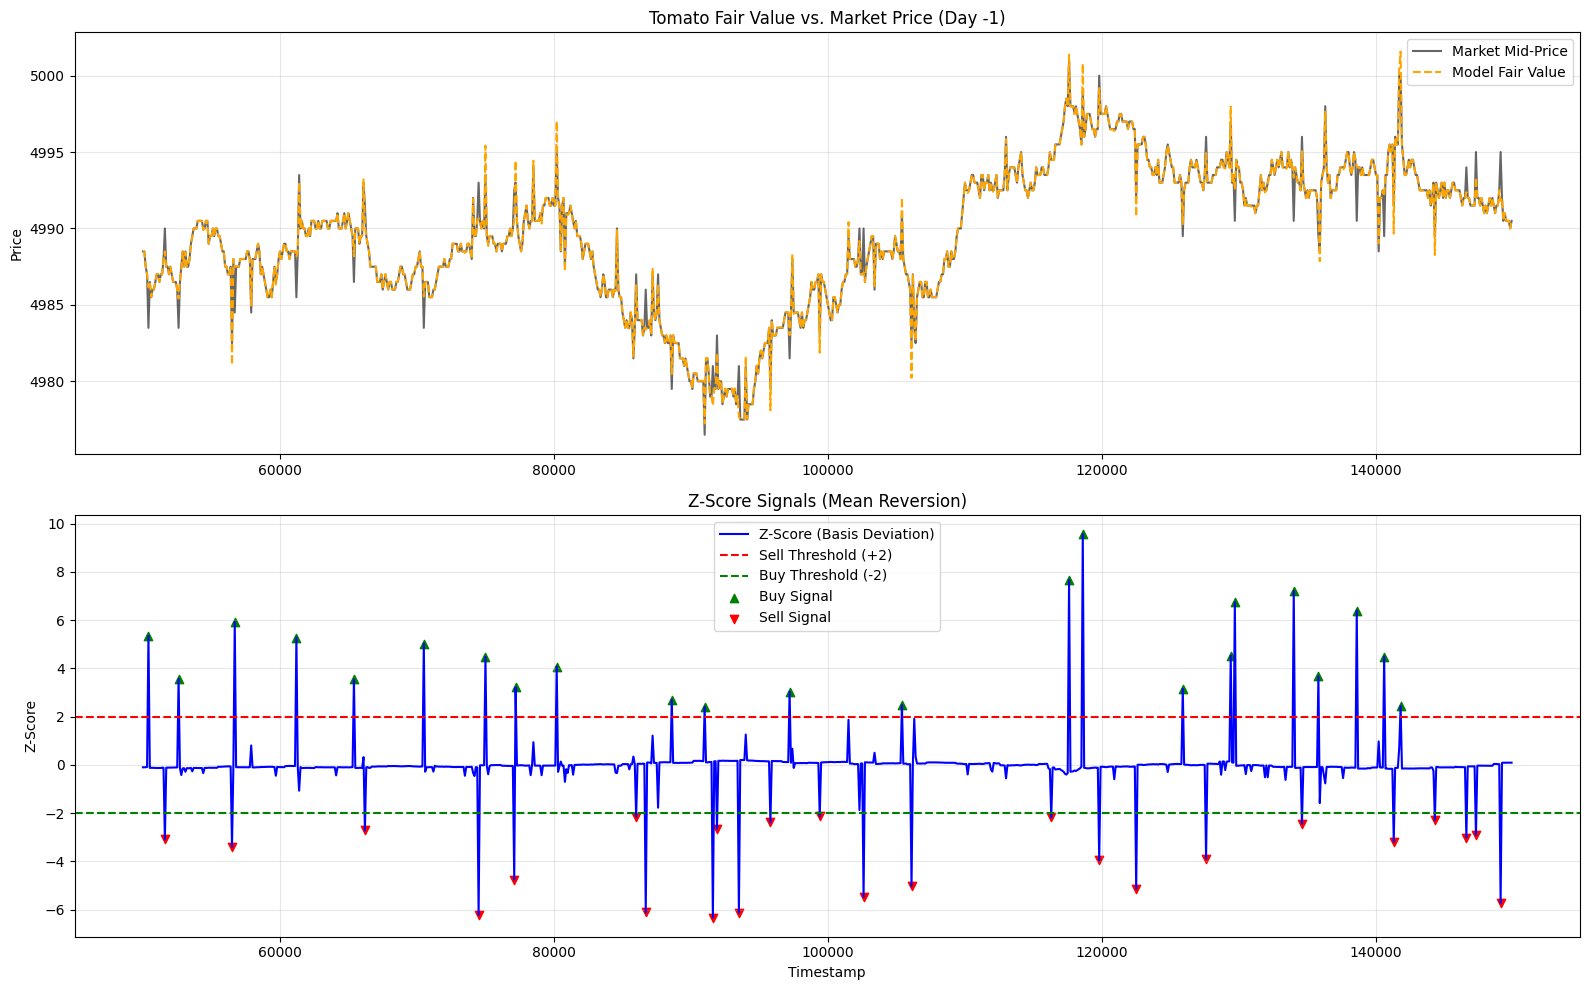

In [12]:
import matplotlib.pyplot as plt

# 7. VISUALIZATION
# Filter for a specific day to make the chart readable (e.g., Day -1)
plot_df = df[df['day'] == -1].iloc[500:1500] # Adjust slice to see different time windows

plt.figure(figsize=(16, 10))

# Subplot 1: Price vs Fair Value
plt.subplot(2, 1, 1)
plt.plot(plot_df['timestamp'], plot_df['mid_price'], label='Market Mid-Price', color='black', alpha=0.6)
plt.plot(plot_df['timestamp'], plot_df['fair_value'], label='Model Fair Value', color='orange', linestyle='--')
plt.title('Tomato Fair Value vs. Market Price (Day -1)')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Z-Score and Signals
plt.subplot(2, 1, 2)
plt.plot(plot_df['timestamp'], plot_df['z_score'], label='Z-Score (Basis Deviation)', color='blue')
plt.axhline(y=2.0, color='red', linestyle='--', label='Sell Threshold (+2)')
plt.axhline(y=-2.0, color='green', linestyle='--', label='Buy Threshold (-2)')

# Highlight signals on the Z-score plot
buys = plot_df[plot_df['signal'] == 1]
sells = plot_df[plot_df['signal'] == -1]
plt.scatter(buys['timestamp'], buys['z_score'], color='green', marker='^', label='Buy Signal')
plt.scatter(sells['timestamp'], sells['z_score'], color='red', marker='v', label='Sell Signal')

plt.title('Z-Score Signals (Mean Reversion)')
plt.xlabel('Timestamp')
plt.ylabel('Z-Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

--- Risk Metrics for Tomato Strategy ---
95% Value at Risk (VaR): 0.0000%
Maximum Drawdown: -0.6089%


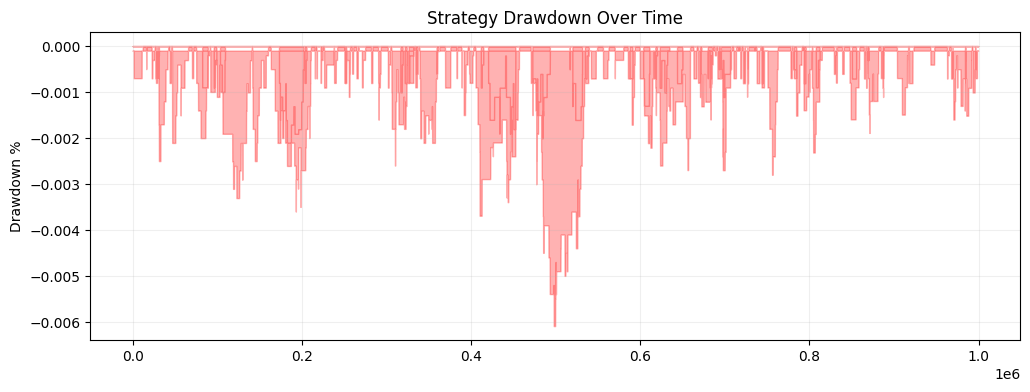

In [13]:
# A. Calculate Strategy Returns
# We assume we go Long (1), Short (-1), or Flat (0) based on the signal
# The return is the change in Mid-Price multiplied by our position
df['strategy_return'] = df['signal'].shift(1) * (df['mid_price'].pct_change())
df['strategy_return'] = df['strategy_return'].fillna(0)

# B. Calculate Cumulative Returns
df['cum_return'] = (1 + df['strategy_return']).cumprod()

# 1. CALCULATE VaR (Historical 95%)
var_95 = np.percentile(df['strategy_return'], 5)

# 2. CALCULATE MAX DRAWDOWN
rolling_max = df['cum_return'].cummax()
drawdown = (df['cum_return'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

print(f"--- Risk Metrics for Tomato Strategy ---")
print(f"95% Value at Risk (VaR): {var_95:.4%}")
print(f"Maximum Drawdown: {max_drawdown:.4%}")

# Optional: Plotting the Drawdown
plt.figure(figsize=(12, 4))
plt.fill_between(df['timestamp'], drawdown, color='red', alpha=0.3)
plt.title('Strategy Drawdown Over Time')
plt.ylabel('Drawdown %')
plt.grid(True, alpha=0.2)
plt.show()

In [14]:
# Run this after your model.fit(X_scaled, y) line
print("--- COPY THESE INTO YOUR TRADER CLASS ---")
print(f"INTERCEPT: {model.intercept_}")

# This pairs the names of your features with their calculated weights (Betas)
coeffs = dict(zip(features, model.coef_))

for feature, value in coeffs.items():
    print(f"BETA_{feature.upper()}: {value}")

--- COPY THESE INTO YOUR TRADER CLASS ---
INTERCEPT: -0.010844528656287428
BETA_FLOW: 0.02617198349396026
BETA_BOOK_IMBALANCE: 0.47201689825879584
BETA_MID_PRICE: -0.05967175921548914


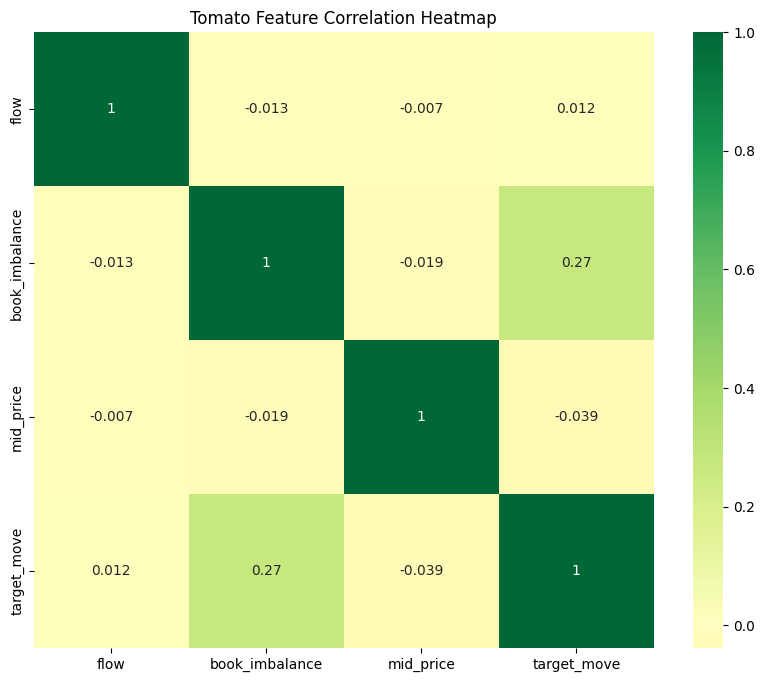

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# We only care about how features correlate with our TARGET (target_move)
cols_to_check = ['flow', 'book_imbalance', 'mid_price', 'target_move']
corr_matrix = df[cols_to_check].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Tomato Feature Correlation Heatmap')
plt.show()

In [17]:
# Re-train with only the winner
X_lean = df[['book_imbalance']] 
y = df['target_move']

model_lean = LinearRegression()
model_lean.fit(X_lean, y)

print(f"NEW_INTERCEPT = {model_lean.intercept_}")
print(f"NEW_BETA_IMBALANCE = {model_lean.coef_[0]}")

NEW_INTERCEPT = -0.009320829220864864
NEW_BETA_IMBALANCE = 5.537481786539028


In [18]:
# --- THE "STOPS THE BLEED" CODE ---

# 1. Calculate the change in price over the next 5 ticks
# We use micro_price because it is more sensitive than mid_price
df['target_move'] = df.groupby('day')['micro_price'].shift(-5) - df['micro_price']

# 2. DROP THE LAST 5 ROWS 
# (Otherwise, the model trains on 'NaN' values and breaks)
df.dropna(subset=['target_move'], inplace=True)

# 3. Use ONLY book_imbalance as the feature (per your 0.27 heatmap)
X = df[['book_imbalance']]
y = df['target_move']

model_lean = LinearRegression()
model_lean.fit(X, y)

print(f"BETA_IMBALANCE = {model_lean.coef_[0]}")
print(f"INTERCEPT = {model_lean.intercept_}")

BETA_IMBALANCE = 5.537474699352795
INTERCEPT = -0.009508631818786474


In [19]:
# Calculate the standard deviation of the 'basis' (Price - Fair Value)
df['basis'] = df['micro_price'] - df['fair_value']
std_basis = df['basis'].std()

print(f"Standard Deviation of Basis: {std_basis}")
print(f"Recommended ENTRY_THRESHOLD (2.5x Sigma): {std_basis * 2.5}")
print(f"Recommended EXIT_THRESHOLD (0.5x Sigma): {std_basis * 0.5}")

Standard Deviation of Basis: 0.47746173779886986
Recommended ENTRY_THRESHOLD (2.5x Sigma): 1.1936543444971746
Recommended EXIT_THRESHOLD (0.5x Sigma): 0.23873086889943493
